# Data Acquisition #
- Topic Choice: NYC 311 Service Request Patterns 
- Dataset URL: https://data.cityofnewyork.us/Social-Services/311-Service-Requests-from-2020-to-Present/erm2-nwe9/about_data 
- Project Proposal: This project will analyze New York City’s 311 Service Request data to investigate non-emergency complaint trends over time, geography, and complaint type throughout the city. The main analytical questions are: 
    - Which complaint categories are most prevalent in each borough? 
    - How do complaint volumes and types shift seasonally? 
    - Which neighborhoods exhibit the largest amounts of unresolved or slow-to-resolve requests? 
- To answer these questions, this project will apply geospatial analysis to produce heatmaps of complaint hotspots, conduct temporal analysis to investigate seasonal and weekly patterns, and compute resolution time distributions by complaint type of borough. The goal is to investigate patterns in how New Yorkers interact with city services which will reveal whether there are systemic delays in issue resolution and whether specific complaint types cluster spatially which may reflect underlying infrastructure conditions. 
- Proof of Dataset download/access: The dataset was downloaded on April 1st, it is a ~13 GB csv file containing all the data

# Data Loading #

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set path for dataset
filepath = "311_Service_Requests_from_2020_to_Present_20260401.csv"

# Use these columns for analysis
usecols = [
    'Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 
    'Problem (formerly Complaint Type)', 'Problem Detail (formerly Descriptor)', 
    'Location Type', 'Incident Zip', 'Borough', 'Status', 'Latitude', 'Longitude'
]

# Load data
df = pd.read_csv(filepath, usecols=usecols, low_memory=False)#, nrows=10000000)

print(f"Data loaded with shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")


Data loaded with shape: (20682653, 13)
Memory Usage: 12986.50 MB


# Data Cleaning #

- Justification: 
    - Rows with missing 'Created Date' or 'Problem' cannot be analyzed temporally or categorically, so they are dropped. 
    - Duplicates are removed to prevent over-counting. 
    - The 'Borough' column is cleaned up as it sometimes uses 'Unspecified'
    - Clean up Zip Codes to make sure they're valid
    - Convert date columns to datetime objects to use in analysis

In [3]:
# Convert datetime columns in datetime objects
df['Created Date'] = pd.to_datetime(df['Created Date'], errors='coerce')
df['Closed Date'] = pd.to_datetime(df['Closed Date'], errors='coerce')

# Handle missing zip codes and make sure they're valid
df['Incident Zip'] = df['Incident Zip'].astype(str).str[:5]
df['Incident Zip'] = df['Incident Zip'].replace('nan', np.nan)

df['Borough'] = df['Borough'].replace('Unspecified', np.nan)

# Drop columns where 'Created Date' or the problem is missing
df.dropna(subset=['Created Date', 'Problem (formerly Complaint Type)'], inplace=True)

# Drop duplicate columns
df.drop_duplicates(inplace=True)

# New shape and memory usage
print(f"New Data Shape: {df.shape}")
print(f"New Memory Usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

New Data Shape: (20682653, 13)
New Memory Usage: 10515.32 MB


## Feature Engineering ##

- Justification:
    - Created resolution time column and removed negative resolution times since they may be a potential data error
    - Kept situations where resolution time is nan where it couldn't be calculated
    - Created columns for day, month, and year for later analysis
    - Created a bin feature for tracking complaints resolved within certain ranges

In [4]:
# Create new column that calculates resolution time in hours
df['ResolutionTimeHours'] = (df['Closed Date'] - df['Created Date']).dt.total_seconds() / 3600
# Remove negative resolution times (potential data entry errors)
df = df[(df['ResolutionTimeHours'] >= 0) | (df['ResolutionTimeHours'].isna())]

# Temporal Features
df['Created Month'] = df['Created Date'].dt.month
df['Created Year'] = df['Created Date'].dt.year
df['Day of Week'] = df['Created Date'].dt.day_name()

# Binning Feature (Categorize Resolution Times for easy plotting)
bins = [-1, 24, 72, 168, 8760, float('inf')]
labels = ['< 1 Day', '1-3 Days', '3-7 Days', '1 Week - 1 Year', '> 1 Year']
df['ResolutionCategory'] = pd.cut(df['ResolutionTimeHours'], bins=bins, labels=labels)

# EDA Visualizations #

In [5]:
# Set Seaborn theme
sns.set_theme(style="whitegrid")

# Summary statistics for resolution time and info about the dataset
df.info()
df[['ResolutionTimeHours']].describe()

<class 'pandas.core.frame.DataFrame'>
Index: 20636337 entries, 0 to 20682652
Data columns (total 18 columns):
 #   Column                                Dtype         
---  ------                                -----         
 0   Unique Key                            int64         
 1   Created Date                          datetime64[ns]
 2   Closed Date                           datetime64[ns]
 3   Agency                                object        
 4   Agency Name                           object        
 5   Problem (formerly Complaint Type)     object        
 6   Problem Detail (formerly Descriptor)  object        
 7   Location Type                         object        
 8   Incident Zip                          object        
 9   Status                                object        
 10  Borough                               object        
 11  Latitude                              float64       
 12  Longitude                             float64       
 13  ResolutionTimeH

,ResolutionTimeHours
count,2.022953e+07
mean,4.732020e+02
std,2.580993e+03
min,0.000000e+00
25%,8.313889e-01
50%,7.873611e+00
75%,8.864222e+01
max,9.430549e+04


## Top 20 Most Frequent Complaints ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_43444/4203683578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topProblems.values, y=topProblems.index, palette="viridis")


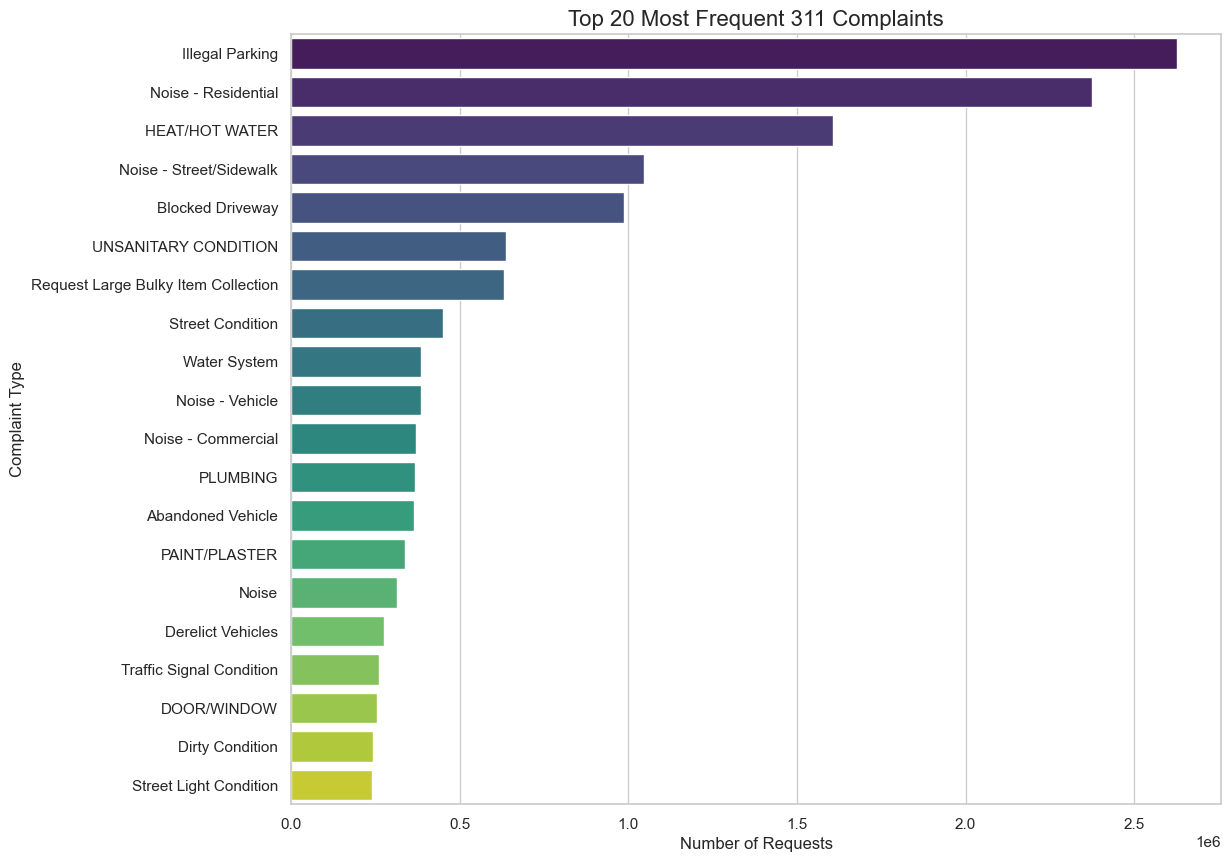

In [6]:
plt.figure(figsize=(12, 10))
topProblems = df['Problem (formerly Complaint Type)'].value_counts().head(20) 
sns.barplot(x=topProblems.values, y=topProblems.index, palette="viridis")
plt.title("Top 20 Most Frequent 311 Complaints", fontsize=16)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("Complaint Type", fontsize=12)
plt.show()

- Interpretation: This bar chart shows the top 20 complaint types that New Yorkes reported most frequently. The most common issues are illegal parking and residential noise with over 2 million requests each. There are also many complaints about heat/hot water, street noise, and blocked driveways. There are many more complaint type categories however, the top 20 capture what NYC sees most reported. 

## Complaints Distribution by Borough ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_43444/3536105001.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=boroughCounts, x='count', y='Borough', palette="magma")


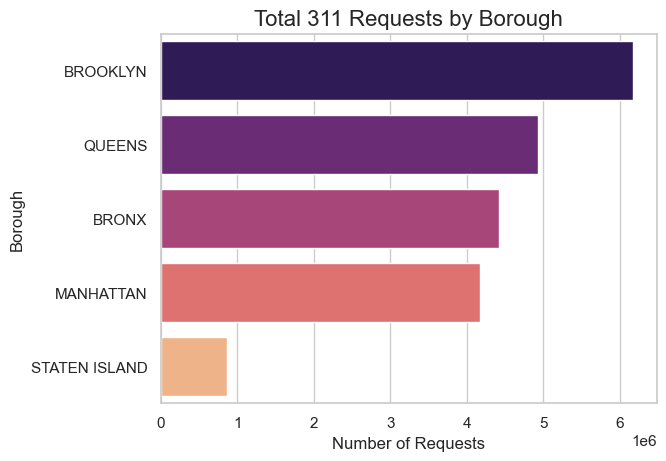

In [7]:
boroughCounts = df['Borough'].value_counts().reset_index()
sns.barplot(data=boroughCounts, x='count', y='Borough', palette="magma")
plt.title("Total 311 Requests by Borough", fontsize=16)
plt.xlabel("Number of Requests", fontsize=12)
plt.ylabel("Borough", fontsize=12)
plt.show()

- Interpretation: This bar chart shows that Brooklyn leads NYC borooughs in total 311 requests, followed by Queens and the Bronx. Staten Island shows an unusually low number of requests compared to the other boroughs. 

## Trend of Complaints Over Time (Monthly) ##

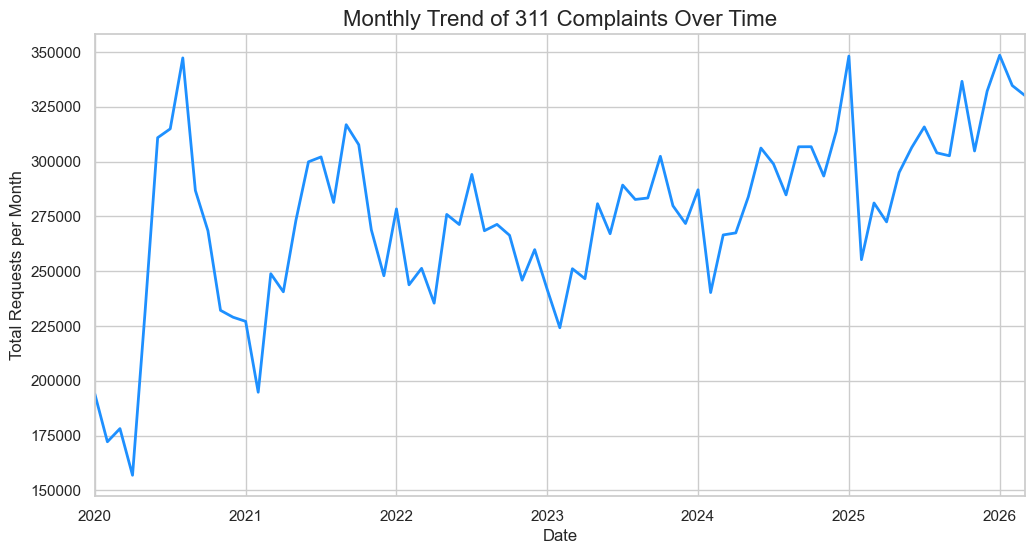

In [8]:
plt.figure(figsize=(12, 6))
df_time = df.set_index('Created Date').resample('ME').size()
df_time.plot(kind='line', color='dodgerblue', linewidth=2)
plt.title("Monthly Trend of 311 Complaints Over Time", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Requests per Month", fontsize=12)
plt.show()

- Interpretation: The line chart shows a rising trend from 2020-2026, with seasonal peaks suggesting there may be recurring issues that drive spikes in complaints. 

## Agencies Handling Requests ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_43444/2064493065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=agenciesCount.index, y=agenciesCount.values, palette="cubehelix")


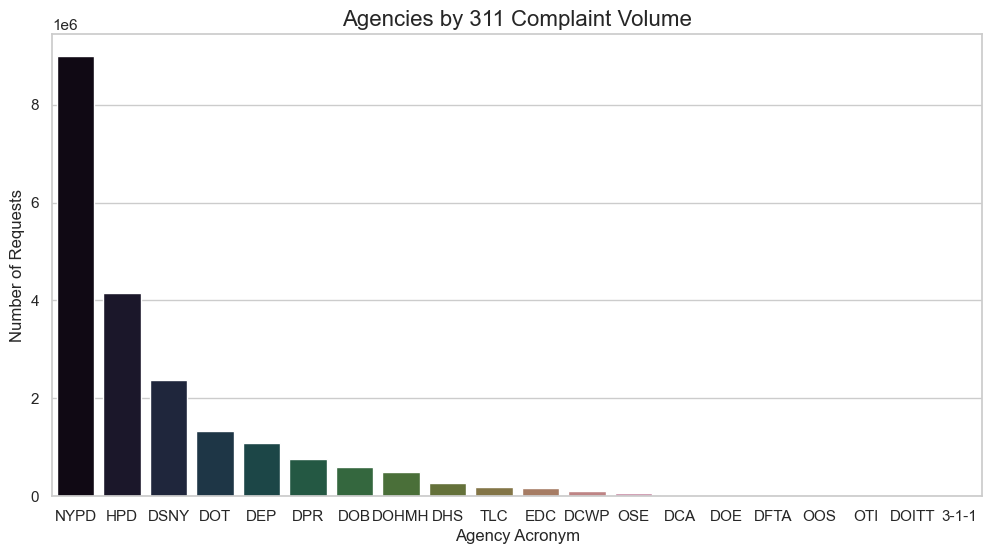

In [9]:
plt.figure(figsize=(12, 6))
agenciesCount = df['Agency'].value_counts()
sns.barplot(x=agenciesCount.index, y=agenciesCount.values, palette="cubehelix")
plt.title("Agencies by 311 Complaint Volume", fontsize=16)
plt.xlabel("Agency Acronym", fontsize=12)
plt.ylabel("Number of Requests", fontsize=12)
plt.show()

- Interpretation: This bar charts shows that a small number of agencies, NYPD, HPD, and DSNY, handle the majority of NYC 311 complaints with NYPD handling more than double the number that HPD does. Most other agencies receive comparatively low volumes of requests.

## Distribution of Resolution Time by Top 10 Agencies ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_43444/1066087054.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_agency, x='Agency', y='LogResolutionTime', order=agencyOrder, palette="muted")


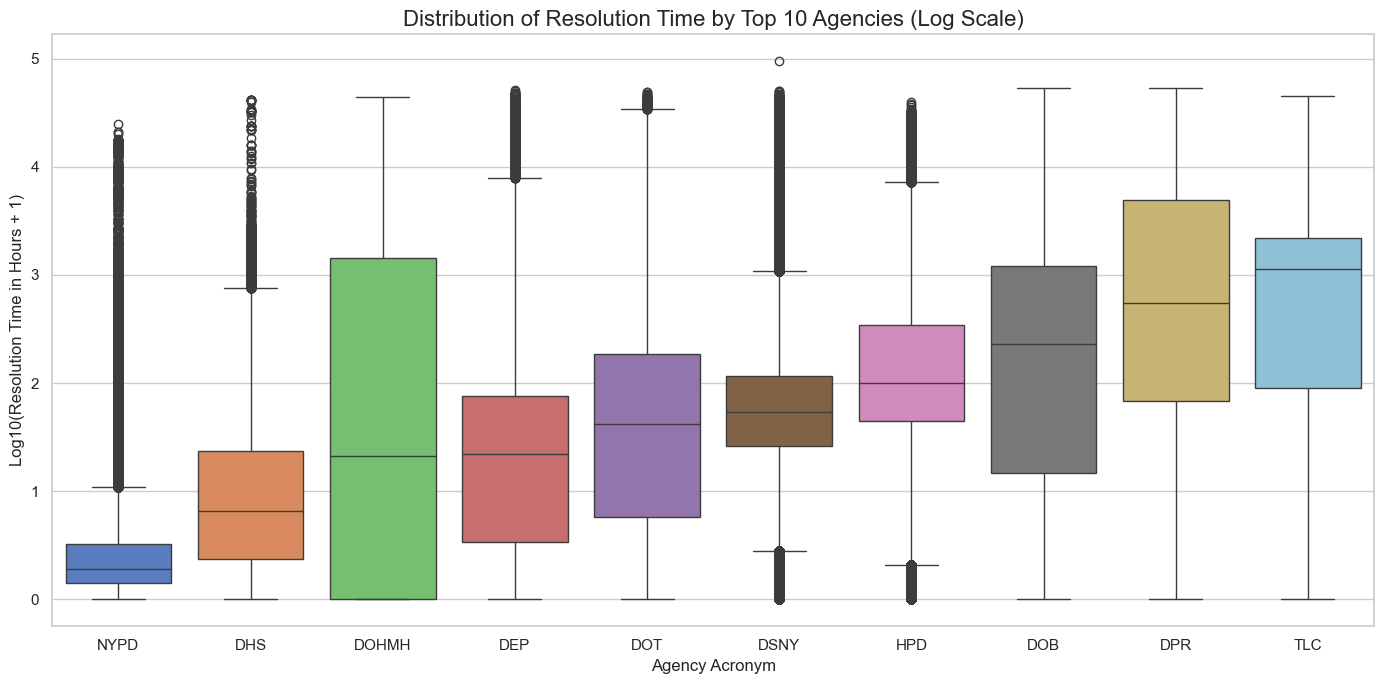

In [10]:
# Identify the top 10 agencies by volume and filter for them and remove missing resolution times
topAgencies = df['Agency'].value_counts().head(10).index
df_agency = df[df['Agency'].isin(topAgencies)].dropna(subset=['ResolutionTimeHours']).copy()

# Add a small constant to avoid log(0) errors
df_agency['LogResolutionTime'] = np.log10(df_agency['ResolutionTimeHours'] + 1)

# Sort by median resolution time
agencyOrder = df_agency.groupby('Agency')['ResolutionTimeHours'].median().sort_values().index

plt.figure(figsize=(14, 7))
sns.boxplot(data=df_agency, x='Agency', y='LogResolutionTime', order=agencyOrder, palette="muted")
plt.title("Distribution of Resolution Time by Top 10 Agencies (Log Scale)", fontsize=16)
plt.xlabel("Agency Acronym", fontsize=12)
plt.ylabel("Log10(Resolution Time in Hours + 1)", fontsize=12)
plt.tight_layout()
plt.show()


- Interpretation: This box plot shows that resolution times differ substantially by agency. NYPD resolves complaints the fastest while agencies like DOHMH, DPR, and TLC show longer and more variable response times. 

## Distribution of Resolution Time for Top 10 Complaints ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_43444/2422753815.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_topClean, y='Problem (formerly Complaint Type)', x='LogResolutionTime', palette="Set2")


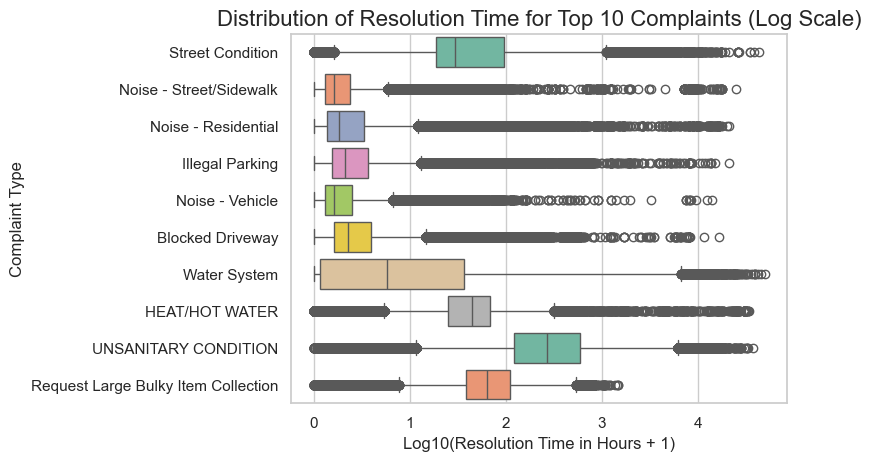

In [11]:
# Identify top 10 complaints by volume and filter
topComplaints = df['Problem (formerly Complaint Type)'].value_counts().head(10).index
df_top = df[df['Problem (formerly Complaint Type)'].isin(topComplaints)]

# Adding a small constant to avoid log(0) and dropping NaNs
df_topClean = df_top.dropna(subset=['ResolutionTimeHours']).copy()
df_topClean['LogResolutionTime'] = np.log10(df_topClean['ResolutionTimeHours'] + 1)

sns.boxplot(data=df_topClean, y='Problem (formerly Complaint Type)', x='LogResolutionTime', palette="Set2")
plt.title("Distribution of Resolution Time for Top 10 Complaints (Log Scale)", fontsize=16)
plt.xlabel("Log10(Resolution Time in Hours + 1)", fontsize=12)
plt.ylabel("Complaint Type", fontsize=12)
plt.show()

- Interpretation: This box plot shows that resolution time varies by complaint type with law enforcement issues showing quick resolution times while infrastrucure related complaints take longer and show more variability. 

## Distribution of Resolution Time by Borough ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_43444/3878852588.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boro, x='Borough', y='LogResolutionTime', order=boro_order, palette="Set3")


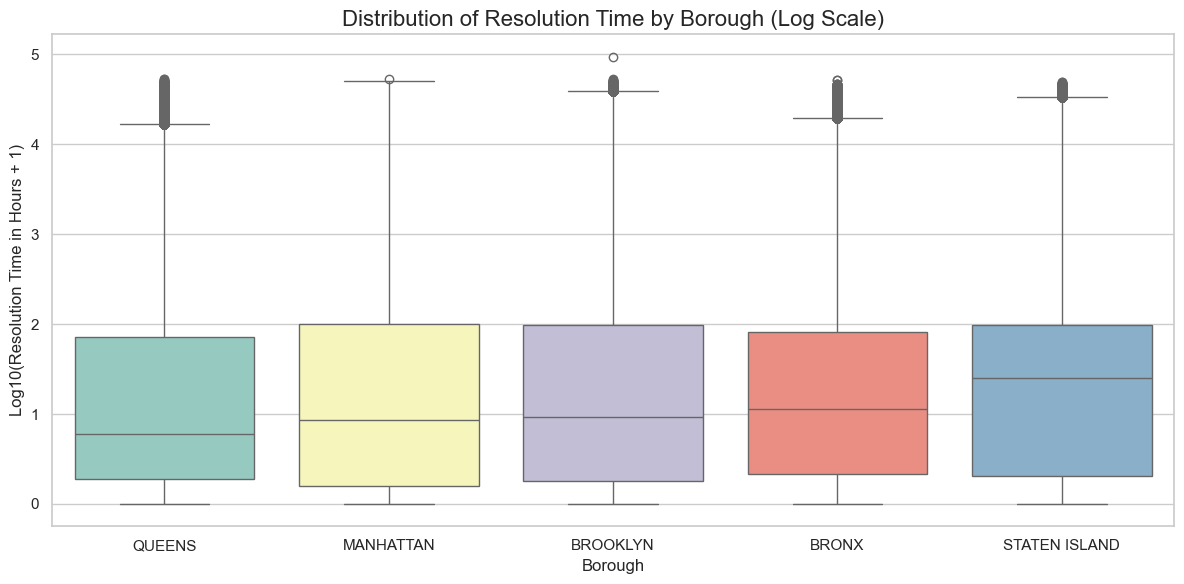

In [12]:
# Drop missing values
df_boro = df.dropna(subset=['Borough', 'ResolutionTimeHours']).copy()

# Add a small constant to avoid log(0) errors
df_boro['LogResolutionTime'] = np.log10(df_boro['ResolutionTimeHours'] + 1)

# Sort by median resolution time
boro_order = df_boro.groupby('Borough')['ResolutionTimeHours'].median().sort_values().index

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_boro, x='Borough', y='LogResolutionTime', order=boro_order, palette="Set3")
plt.title("Distribution of Resolution Time by Borough (Log Scale)", fontsize=16)
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Log10(Resolution Time in Hours + 1)", fontsize=12)
plt.tight_layout()
plt.show()


- Interpretation: This box plot shows that resolution times are fairly consistent across NYC boroughs, with very minor differences. This combined with the data in total complaints by borough show that response time isn't affected by the volume of complaints from a borough. 

## Complaints by Resolution Time Category ##

/var/folders/dr/l7061z6x155_nwbh9k4h_b4c0000gn/T/ipykernel_43444/2515818423.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=resCounts.index, y=resCounts.values, palette="pastel")


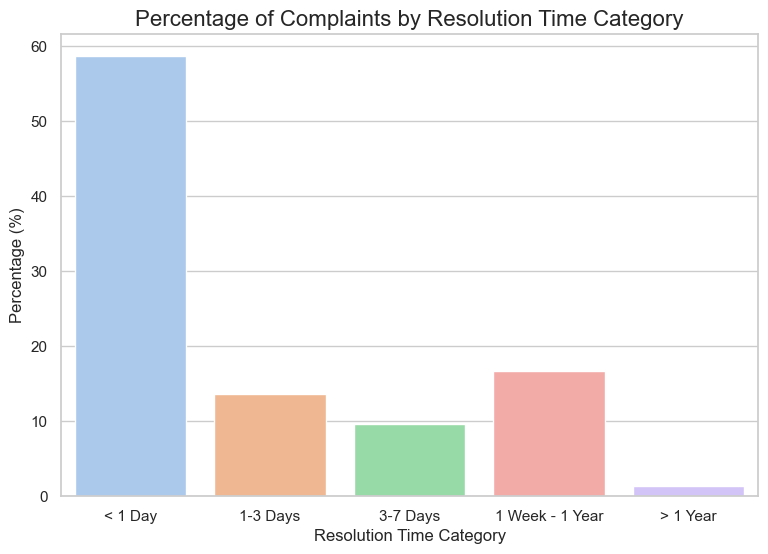

In [13]:
resCounts = df['ResolutionCategory'].value_counts(normalize=True) * 100

plt.figure(figsize=(9, 6))
sns.barplot(x=resCounts.index, y=resCounts.values, palette="pastel")
plt.title("Percentage of Complaints by Resolution Time Category", fontsize=16)
plt.xlabel("Resolution Time Category", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.show()

- Interpretation: This bar chart shows that most NYC 311 complaints are resolved within a day. Some complaints take longer (up to a week), and a meaningful amount extend up to a year. Complaints lasting longer than a year make up a very small portion of total complaints. 

## Heatmap of Top Complaints Across Boroughs ##

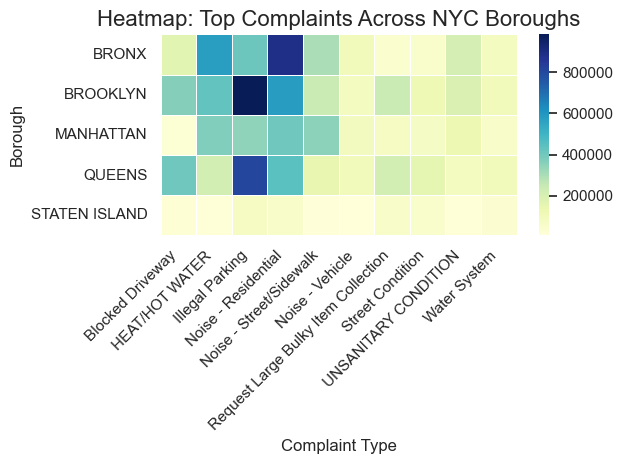

In [14]:
heatmapData = df_top.groupby(['Borough', 'Problem (formerly Complaint Type)']).size().unstack(fill_value=0)
sns.heatmap(heatmapData, annot=False, cmap="YlGnBu", linewidths=.5)
plt.title("Heatmap: Top Complaints Across NYC Boroughs", fontsize=16)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Borough", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Interpretation: This heatmap shows that Brooklyn has a high number of illegal parking complaints followed by Queens. The Bronx has a significant number of residential noise issues and heat/hot water copmlaints potentially revealing an underlying infrastructure issue. Staten Island shows a comparatively low number of complaints across all categories. 

## Top Complaints by Month ##

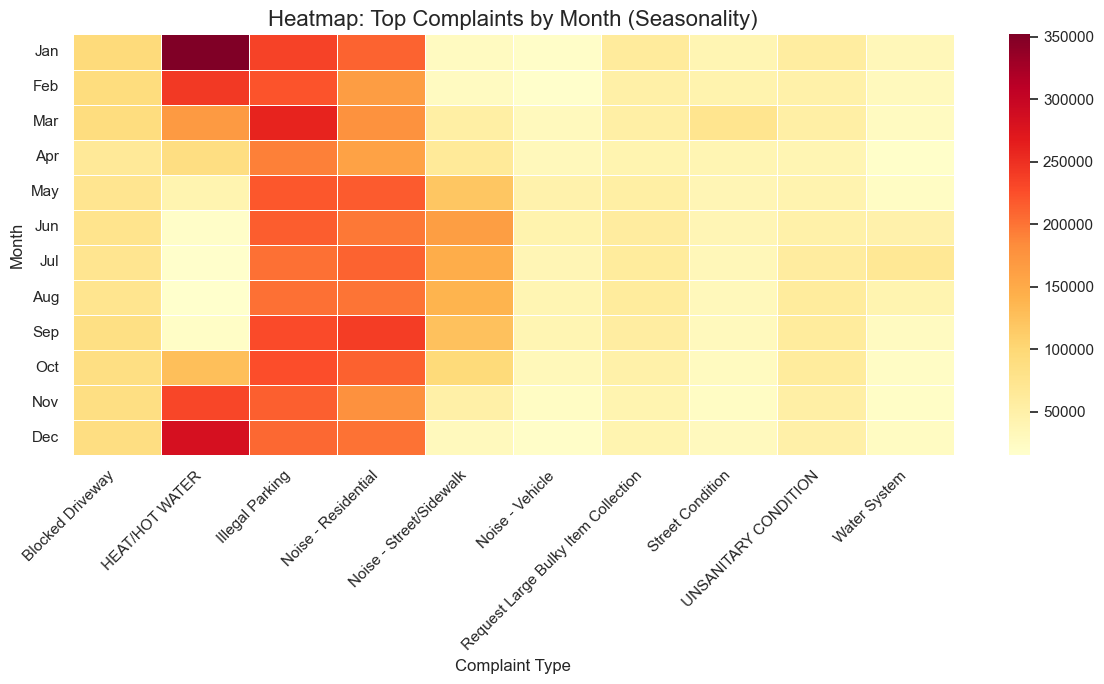

In [15]:
# Group by the engineered 'Created Month' and 'Complaint Type', then unstack to create a matrix
monthly_complaints = df_top.groupby(['Created Month', 'Problem (formerly Complaint Type)']).size().unstack(fill_value=0)
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 7))
sns.heatmap(monthly_complaints, annot=False, cmap="YlOrRd", linewidths=.5)
plt.yticks(ticks=np.arange(0.5, 12.5), labels=months, rotation=0)
plt.title("Heatmap: Top Complaints by Month (Seasonality)", fontsize=16)
plt.xlabel("Complaint Type", fontsize=12)
plt.ylabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Interpretation: This heatmap of complaints by month reveals some clear seasonal trends
    - Heat/Hot water complaints spike sharply during Winter months (November - February)
    - Street/Sidewalk complaints rise during the Spring and Summer months potentially due to more outdoor acitivity by residents of NYC.
    - Parking-related complaints are consistent year round

## Correlation Matrix of Numeric Features ##

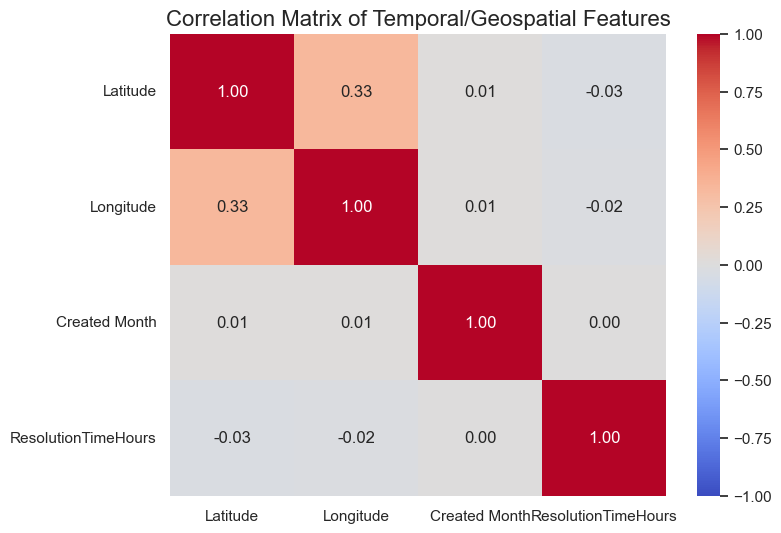

In [16]:
# Select numeric columns for linear correlation
corrCols = ['Latitude', 'Longitude', 'Created Month', 'ResolutionTimeHours']
corrData = df[corrCols].dropna().corr()

# Use 'coolwarm' cmap for correlations (diverging)
plt.figure(figsize=(8, 6)) 
sns.heatmap(corrData, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Temporal/Geospatial Features", fontsize=16)
plt.show()


- Interpretation: Linear correlation is generally weak across the board which confirms that resolution times are not strictly dictated by geospatial corrdinateso or the month of the year. This implies that categorical factos like agency or type dictate resolution times. 

# Summary #
- **EDA Summary**: 
    - Some 311 complaints are localized by category:
        - Illegal Parking is most common in Brooklyn and Queens
        - Residential noise and heat/hot water complaints are most common in the Bronx
    - Some 311 complaints are seasonal:
        - Spike in heat/hot water complaints in the Winter due to extra usage by all New Yorkers. 
        - Extra street/sidewalk noise complaints in the Spring and Summer months potentially due to increased outdoor activity during the Spring and Summer. 
    - Resolution times are primarily dictated by the responding issues and type of issue. NYPD resolves issues that fastest while more infrastructure focused agencies take longer to resolve issues and with more variable time.
    - Clear increase in complaints over the years between 2020 - 2026.
    - Seasonal spikes in total number of complaints between 2020-2026. 
    - Little to no difference in resolution time of complaints between boroughs.
    - Most complaints are resolved within a day, with a smaller number taking up to a week, and a smaller portion taking up to over a year.
    - NYPD resolves the most complaints
    - Brooklyn has the most total complaints
    - Illegal parking is complained about the most

- **Methodological Assumptions**:
    - Assumed that negative resolutions times were due to data-entry errors so they were dropped
    - Assumed that the resolution time in hours is a good measure of efficiency of the agency. In reality, this could be attributed to agencies tackling issues that naturally take longer to resolve. 

- **Data Limitations & Scope**:
    - Limitation: 311 data only captures reported issues so not all actual issues that are faced by New Yorkers may be recorded. Some neigborhoods may tend to report more or less due to factors like language barriers of lack of trust in city services which means a lower volume of complaints will come naturally.
    - Scope: The scope of this data is limited to 2020-2026 so the data between 2020-2021 may be skewed due to the COVID-19 pandemic lockdowns, which may have altered behaviors. 

- **Hypotheses for Further Exploration**:
    - Complaint types may vary significantly based on median income of the ZIP code. Lower-income ZIP codes may report more housing or maintainence related issues whereas higher-income areas may report more quality-of-life or noise issues. 
    - Infrastructure complaints may be tightly clustered in older neighborhoods rather than uniformly distributed across a borough. 